# PsiQuantum Stack: Construct, PsiQDK, Bartiq, QREF

This notebook separates the PsiQuantum stack into platform, SDK, schema, and symbolic aggregation layers.

Corpus anchors: `QRE2`, `QRE4`, `IO4`, `IO5`, `IO7`, `IO8`, `PRIM14`, `PRIM15`, `PRIM16`.

Compact object: a QREF/Bartiq route skeleton for periodic Taylor-Green resource bookkeeping.


## Construct, PsiQDK, Workbench, QREF, And Bartiq

This is the naming stack we will use when explaining the PsiQuantum ecosystem.

Construct is the umbrella platform. PsiQuantum presents Construct as an open-access software platform for fault-tolerant quantum algorithm design, circuit design, resource estimation, and algorithm optimization. It is not one monolithic package that we install into this repository. It is the entry point for separate tools: Circuit Designer, QDK with Workbench, Resource Analyzer, documentation, education, and community support.

PsiQDK is the Python SDK inside that ecosystem. Workbench is the FTQC-native runtime/programming layer inside PsiQDK: it lets us write FTQC programs, simulate them, compile and optimize operations, and emit logical resource estimates. In this project, PsiQDK/Workbench is a WSL sandbox tool, not a native Windows project dependency.

QREF and Bartiq are lighter and more specialized. QREF is a schema/data format for hierarchical resource-estimation routine trees. Bartiq is a symbolic compiler/evaluator that aggregates local symbolic formulas into global resource costs.

| Need | Best PsiQuantum tool | Project posture |
| --- | --- | --- |
| Explain the ecosystem to supervisors | Construct web platform | Use as umbrella and web entrypoint. |
| Draw or inspect teaching circuits | Circuit Designer or Workbench visualization | Good for communication, not route validation. |
| Write PsiQuantum-native FTQC toy programs | PsiQDK / Workbench | Run in WSL sandbox. |
| Express route boxes before circuits exist | QREF | Promoted for private bookkeeping. |
| Aggregate symbolic costs | Bartiq | Promoted for private bookkeeping. |
| Compare final estimates visually | Resource Analyzer | Use after estimates and assumptions exist. |

Supervisor-ready summary:

> Construct is PsiQuantum's umbrella software platform for fault-tolerant quantum algorithm design, resource estimation, and optimization. PsiQDK and Workbench are the Python SDK/runtime inside that ecosystem for writing and analyzing FTQC programs. QREF is a schema for expressing resource-estimation routine trees, while Bartiq is a symbolic compiler/evaluator that aggregates local resource formulas into global costs. For this project, Bartiq/QREF are lightweight enough for maintained symbolic bookkeeping, while PsiQDK is better treated as a WSL sandbox until a QCFD route requires PsiQuantum-native primitives.

Sources: [Construct](https://construct.psiquantum.com/), [PsiQDK / Workbench](https://construct.psiquantum.com/qdk), [Bartiq](https://psiq.github.io/bartiq/latest/), [QREF](https://pypi.org/project/qref/).

Tool roles:

| Tool | Role |
| --- | --- |
| Construct | Open-access FTQC platform: Circuit Designer, PsiQDK/Workbench, Resource Analyzer. |
| PsiQDK / Workbench | Python FTQC SDK and algorithm library, currently WSL/Linux in this project. |
| QREF | Schema for hierarchical resource-estimation routine trees. |
| Bartiq | Compiler/evaluator for symbolic resource formulas over QREF-like routines. |

Teaching equation:

```text
T_total = T_load + N_t (T_stream + T_collide + T_success) + N_samples T_readout_sample
```


tooling atlas output directory: .cache/tooling_atlas


{
  "lattice_populations": 9216,
  "logical_qubits": 47,
  "success_probability_placeholder": 0.970342987093574,
  "state_loads": 1,
  "t_count": 47500,
  "samples": 1000
}


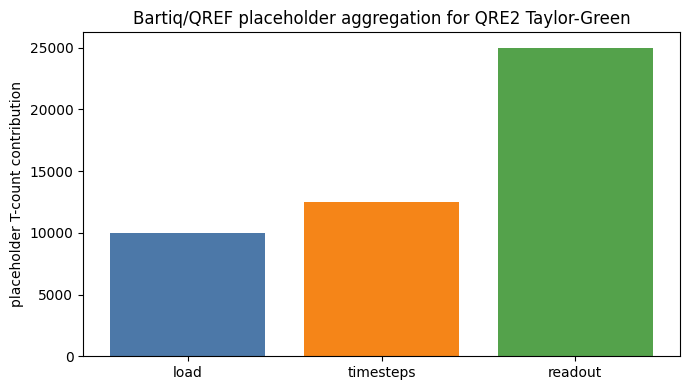

falsifiable check: Bartiq aggregate equals the explicit placeholder component sum


In [1]:
from pathlib import Path
import importlib.util
import json
import math

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('.cache/tooling_atlas')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except ModuleNotFoundError:
        return False


print(f'tooling atlas output directory: {OUTPUT_DIR}')

from pq_cfd import _bartiq_qref_resources as qre2_resources

assignments = {
    'N_x': 32, 'N_y': 32, 'N_t': 10, 'N_samples': 1000,
    'q_site': 10, 'q_velocity': 4, 'q_population': 8, 'q_work': 20, 'q_observable': 5,
    'T_load': 10_000, 'T_stream': 200, 'T_collide': 1_000, 'T_success': 50,
    'T_readout_sample': 25, 'p_load': 0.99, 'p_step': 0.999, 'p_readout': 0.99,
}
routine = qre2_resources.evaluate_qre2_taylor_green_route(assignments)
resources = {name: resource.value for name, resource in routine.resources.items()}
print(json.dumps(resources, indent=2, default=str))

components = {
    'load': assignments['T_load'],
    'timesteps': assignments['N_t'] * (assignments['T_stream'] + assignments['T_collide'] + assignments['T_success']),
    'readout': assignments['N_samples'] * assignments['T_readout_sample'],
}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(components.keys(), components.values(), color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_ylabel('placeholder T-count contribution')
ax.set_title('Bartiq/QREF placeholder aggregation for QRE2 Taylor-Green')
plt.tight_layout()
plt.show()

assert routine.resources['t_count'].value == sum(components.values())
assert qre2_resources.PLACEHOLDER_NOTICE in qre2_resources.qre2_taylor_green_route_tree()['program']['meta']['notice']
print('falsifiable check: Bartiq aggregate equals the explicit placeholder component sum')


In [2]:
# Corpus anchors: PRIM14, PRIM15, PRIM16. Environment check for PsiQuantum-stack demos.
import importlib.metadata as metadata

packages = [
    ('bartiq', 'Bartiq symbolic resource aggregation'),
    ('qref', 'QREF schema validation'),
    ('psiqdk', 'PsiQDK umbrella package'),
    ('psiqdk-workbench', 'Workbench runtime'),
    ('psiqdk-algorithms', 'Workbench Algorithms'),
    ('psiqdk-visualize', 'PsiQDK visualization tools'),
]

for package, role in packages:
    try:
        version = metadata.version(package)
    except metadata.PackageNotFoundError:
        version = 'not installed in this Python environment'
    print(f'{package:18s} {version:>35s}  - {role}')

print('Interpretation: Bartiq/QREF should be live in the main Windows env; PsiQDK should be live in the WSL sandbox.')

bartiq                                          0.17.0  - Bartiq symbolic resource aggregation
qref                                            0.11.0  - QREF schema validation
psiqdk                                           2.0.0  - PsiQDK umbrella package
psiqdk-workbench                                4.45.0  - Workbench runtime
psiqdk-algorithms                               1.22.3  - Workbench Algorithms
psiqdk-visualize                                0.97.2  - PsiQDK visualization tools
Interpretation: Bartiq/QREF should be live in the main Windows env; PsiQDK should be live in the WSL sandbox.


In [3]:
# Optional live PsiQDK / Workbench demo. This is expected to run in the WSL sandbox, not native Windows.
if has_module('psiqdk'):
    try:
        from psiqdk.workbench import QPU, Qubits
        qpu = QPU(num_qubits=2, filters=['>>buffer>>'])
        reg = Qubits(2, 'reg', qpu=qpu)
        reg[0].had()
        reg[1].x(cond=reg[0])
        print('PsiQDK Workbench available; buffered instruction demo:')
        qpu.print_instructions(format='asm')
    except Exception as exc:
        print('PsiQDK import worked, but the Workbench demo failed:', type(exc).__name__, exc)
else:
    print('PsiQDK not installed in this Python. Run from WSL with .cache/psiqdk-uv-venv/bin/python for the live Workbench demo.')


PsiQDK Workbench available; buffered instruction demo:
qc.reset(num_qubits=2)
qc.qubits_alloc(target_mask=0x3, label="reg")
qc.had(target_mask=0x1)
qc.x(target_mask=0x2, condition_mask=0x1)



## What This Cannot Prove

The Bartiq/QREF numbers are placeholders, not `QRE2` resource estimates. PsiQDK can demonstrate FTQC programming primitives, but it cannot make CFD loading, normalization, or selected-observable readout assumptions valid without a route note.
